In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns   # 今天的新朋友：专门画漂亮图的库

# 设置全局显示选项
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', 20)

print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
print("✅ 准备完成")

pandas: 3.0.2
seaborn: 0.13.2
✅ 准备完成


## 1.下载5个ETF的3年数据

In [2]:
tickers = ["VOO", "VXUS", "GLD", "TLT", "VGSH"]

# 批量下载，period 改成 3 年（数据多一点，结果更稳）
raw = yf.download(tickers, period="3y", auto_adjust=True)

print(f"原始数据形状: {raw.shape}")
print(f"列结构:\n{raw.columns[:10]}")   # 看前 10 个列名长什么样
raw.head(3)

[*********************100%***********************]  5 of 5 completed

原始数据形状: (753, 25)
列结构:
MultiIndex([('Close',  'GLD'),
            ('Close',  'TLT'),
            ('Close', 'VGSH'),
            ('Close',  'VOO'),
            ('Close', 'VXUS'),
            ( 'High',  'GLD'),
            ( 'High',  'TLT'),
            ( 'High', 'VGSH'),
            ( 'High',  'VOO'),
            ( 'High', 'VXUS')],
           names=['Price', 'Ticker'])


Price         Close                                      High                  \
Ticker          GLD     TLT    VGSH      VOO    VXUS      GLD     TLT    VGSH   
Date                                                                            
2023-04-24 184.8100 93.3485 51.9251 364.1200 50.9756 185.0300 93.4194 51.9340   
2023-04-25 185.7500 94.7212 52.1384 358.3665 50.1689 186.2200 94.8717 52.1473   
2023-04-26 184.7400 93.7117 52.0673 356.7720 50.2323 186.6500 94.9692 52.1295   

Price                        ...     Open                                   \
Ticker          VOO    VXUS  ...      GLD     TLT    VGSH      VOO    VXUS   
Date                         ...                                             
2023-04-24 364.4850 50.9756  ... 184.0700 92.9500 51.9073 363.5341 50.8578   
2023-04-25 362.7849 50.6130  ... 184.8400 94.1633 52.0139 362.2854 50.6130   
2023-04-26 359.8841 50.5496  ... 186.6300 94.5707 52.1295 358.9044 50.5133   

Price        Volume                                       
Ticker          GLD       TLT     VGSH      VOO     VXUS  
Date                                                      
2023-04-24  8303400  17034300  1471000  2310400  2052900  
2023-04-25  8451900  21899900  2037000  3795400  1950600  
2023-04-26  8203600  19610400  2334700  3766900  1826700  

[3 rows x 25 columns]

In [3]:
prices=raw['Close']  #只保留收盘价

print(f"价格矩阵形状:{prices.shape}")
print(f"价格范围:{prices.index[0].date()}→{prices.index[-1].date()}")
prices.head()


价格矩阵形状:(753, 5)
价格范围:2023-04-24→2026-04-23


Ticker,GLD,TLT,VGSH,VOO,VXUS
Date,,,,,
2023-04-24,184.8100,93.3485,51.9251,364.1200,50.9756
2023-04-25,185.7500,94.7212,52.1384,358.3665,50.1689
2023-04-26,184.7400,93.7117,52.0673,356.7720,50.2323
2023-04-27,184.7500,92.7818,51.9606,363.8510,50.8759
2023-04-28,184.8000,94.2784,52.0228,366.9631,50.9847


缺失值统计:
Ticker
GLD     0
TLT     0
VGSH    0
VOO     0
VXUS    0
dtype: int64

价格范围:
Ticker      GLD     TLT    VGSH      VOO    VXUS
min    168.8300 74.5401 51.4826 356.7720 47.0315
max    495.9000 94.7212 58.6431 653.9000 84.1127
mean   267.0498 86.0928 55.0049 504.0183 61.1099


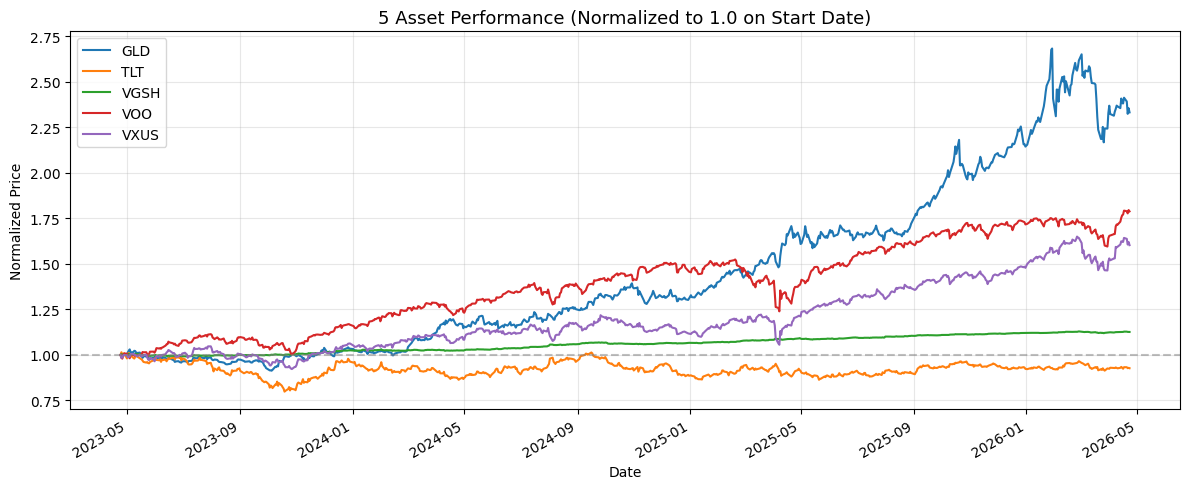

In [4]:
# 1. 有没有缺失值？
print("缺失值统计:")
print(prices.isnull().sum())

# 2. 看看每列的基本信息
print("\n价格范围:")
print(prices.describe().loc[['min', 'max', 'mean']])

# 3. 画一张"起点归一化"的走势图，看看 3 年走势
normalized = prices / prices.iloc[0]   # 每列都除以第一天的价格
normalized.plot(figsize=(12, 5), linewidth=1.5)
plt.title('5 Asset Performance (Normalized to 1.0 on Start Date)', fontsize=13)
plt.ylabel('Normalized Price')
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## 2.计算收益率+对比5个资产的风险收益指标

In [5]:
# 一行搞定 5 个资产的日收益率！
returns = prices.pct_change().dropna()

print(f"收益率矩阵形状: {returns.shape}")
returns.head()

收益率矩阵形状: (752, 5)


Ticker,GLD,TLT,VGSH,VOO,VXUS
Date,,,,,
2023-04-25,0.0051,0.0147,0.0041,-0.0158,-0.0158
2023-04-26,-0.0054,-0.0107,-0.0014,-0.0044,0.0013
2023-04-27,0.0001,-0.0099,-0.0020,0.0198,0.0128
2023-04-28,0.0003,0.0161,0.0012,0.0086,0.0021
2023-05-01,-0.0045,-0.0288,-0.0022,-0.0007,-0.0020


In [6]:
def compute_metrics(ret_series, risk_free=0.03, trading_days=252):
    """
    给定一个收益率 Series，返回一个字典包含所有关键指标
    """
    ret = ret_series.dropna()
    
    # 年化收益与波动
    ann_return = ret.mean() * trading_days
    ann_vol = ret.std() * np.sqrt(trading_days)
    
    # Sharpe
    sharpe = (ann_return - risk_free) / ann_vol
    
    # Sortino（只用下行波动）
    downside_vol = ret[ret < 0].std() * np.sqrt(trading_days)
    sortino = (ann_return - risk_free) / downside_vol if downside_vol > 0 else np.nan
    
    # 最大回撤
    cum = (1 + ret).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    max_dd = dd.min()
    
    # Calmar
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    
    return {
        "Ann Return": ann_return,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max DD": max_dd,
        "Calmar": calmar
    }

# 测试一下：算 VOO 的指标
compute_metrics(returns['VOO'])

{'Ann Return': np.float64(0.20588936839478378),
 'Ann Vol': np.float64(0.14851157439601909),
 'Sharpe': np.float64(1.184347880696217),
 'Sortino': np.float64(1.5915456915359751),
 'Max DD': np.float64(-0.18689403311786),
 'Calmar': np.float64(1.101636927407655)}

In [7]:
# 用 .apply() 把函数作用到每一列
metrics_table = returns.apply(compute_metrics).T

# 稍微美化一下
metrics_table['Ann Return'] = metrics_table['Ann Return'].map(lambda x: f"{x*100:.2f}%")
metrics_table['Ann Vol']    = metrics_table['Ann Vol'].map(lambda x: f"{x*100:.2f}%")
metrics_table['Max DD']     = metrics_table['Max DD'].map(lambda x: f"{x*100:.2f}%")
metrics_table['Sharpe']     = metrics_table['Sharpe'].map(lambda x: f"{x:.2f}")
metrics_table['Sortino']    = metrics_table['Sortino'].map(lambda x: f"{x:.2f}")
metrics_table['Calmar']     = metrics_table['Calmar'].map(lambda x: f"{x:.2f}")

metrics_table

KeyError: 'Ann Return'

In [8]:
metrics_table = returns.apply(compute_metrics).T
print(f"形状: {metrics_table.shape}")
print(f"列名: {metrics_table.columns.tolist() if hasattr(metrics_table, 'columns') else 'N/A'}")
print(metrics_table)

形状: (5,)
列名: N/A
Ticker
GLD     {'Ann Return': 0.3035947834813108, 'Ann Vol': ...
TLT     {'Ann Return': -0.015204169402409193, 'Ann Vol...
VGSH    {'Ann Return': 0.039989814785636436, 'Ann Vol'...
VOO     {'Ann Return': 0.20588936839478378, 'Ann Vol':...
VXUS    {'Ann Return': 0.16900421566756946, 'Ann Vol':...
dtype: object


In [9]:
def compute_metrics(ret_series, risk_free=0.03, trading_days=252):
    """
    给定一个收益率 Series，返回一个 Series 包含所有关键指标
    """
    ret = ret_series.dropna()
    
    ann_return = ret.mean() * trading_days
    ann_vol = ret.std() * np.sqrt(trading_days)
    sharpe = (ann_return - risk_free) / ann_vol
    
    downside_vol = ret[ret < 0].std() * np.sqrt(trading_days)
    sortino = (ann_return - risk_free) / downside_vol if downside_vol > 0 else np.nan
    
    cum = (1 + ret).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    
    # 👇 关键修改：用 pd.Series 而不是 dict
    return pd.Series({
        "Ann Return": ann_return,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max DD": max_dd,
        "Calmar": calmar
    })

In [10]:
metrics_table = returns.apply(compute_metrics).T

# 先看原始数据（不格式化）确认结构对了
print(metrics_table)

        Ann Return  Ann Vol  Sharpe  Sortino  Max DD  Calmar
Ticker                                                      
GLD         0.3036   0.1976  1.3846   1.7097 -0.1921  1.5804
TLT        -0.0152   0.1424 -0.3174  -0.4911 -0.2131 -0.0714
VGSH        0.0400   0.0172  0.5798   0.9591 -0.0155  2.5784
VOO         0.2059   0.1485  1.1843   1.5915 -0.1869  1.1016
VXUS        0.1690   0.1471  0.9447   1.3424 -0.1358  1.2445


In [11]:
metrics_table['Ann Return'] = metrics_table['Ann Return'].map(lambda x: f"{x*100:.2f}%")
metrics_table['Ann Vol']    = metrics_table['Ann Vol'].map(lambda x: f"{x*100:.2f}%")
metrics_table['Max DD']     = metrics_table['Max DD'].map(lambda x: f"{x*100:.2f}%")
metrics_table['Sharpe']     = metrics_table['Sharpe'].map(lambda x: f"{x:.2f}")
metrics_table['Sortino']    = metrics_table['Sortino'].map(lambda x: f"{x:.2f}")
metrics_table['Calmar']     = metrics_table['Calmar'].map(lambda x: f"{x:.2f}")

metrics_table

,Ann Return,Ann Vol,Sharpe,Sortino,Max DD,Calmar
Ticker,,,,,,
GLD,30.36%,19.76%,1.38,1.71,-19.21%,1.58
TLT,-1.52%,14.24%,-0.32,-0.49,-21.31%,-0.07
VGSH,4.00%,1.72%,0.58,0.96,-1.55%,2.58
VOO,20.59%,14.85%,1.18,1.59,-18.69%,1.10
VXUS,16.90%,14.71%,0.94,1.34,-13.58%,1.24


In [12]:
corr_matrix = returns.corr()
print(corr_matrix.round(3))

Ticker    GLD    TLT    VGSH     VOO   VXUS
Ticker                                     
GLD    1.0000 0.1450  0.2500  0.1230 0.3640
TLT    0.1450 1.0000  0.6310  0.1220 0.2140
VGSH   0.2500 0.6310  1.0000 -0.0950 0.0930
VOO    0.1230 0.1220 -0.0950  1.0000 0.7770
VXUS   0.3640 0.2140  0.0930  0.7770 1.0000


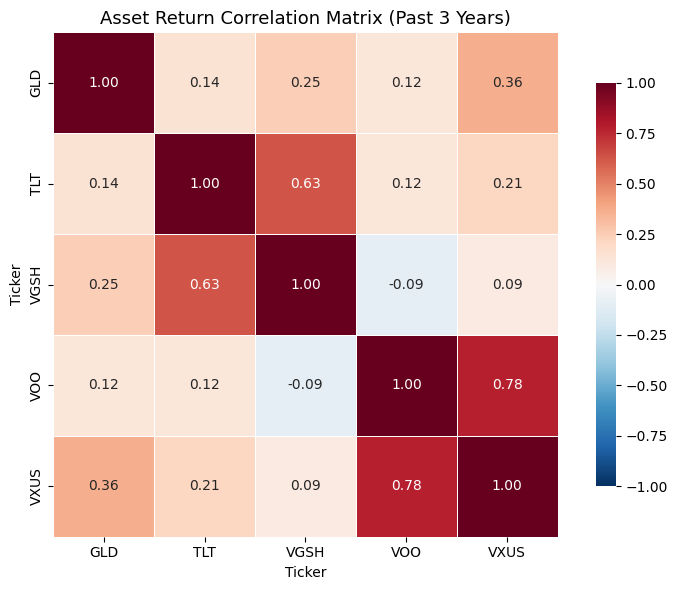

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
ax.set_title('Asset Return Correlation Matrix (Past 3 Years)', fontsize=13)
plt.tight_layout()
plt.show()

## 4.Markowitz 魔法:50/50 VOO+GLD 组合

In [14]:
# 1. 构造 50/50 组合的日收益率
weights = {"VOO": 0.5, "GLD": 0.5}
portfolio_returns = sum(returns[t] * w for t, w in weights.items())

# 2. 用之前写好的函数算指标
voo_metrics = compute_metrics(returns['VOO'])
gld_metrics = compute_metrics(returns['GLD'])
port_metrics = compute_metrics(portfolio_returns)

# 3. 做一个小对比表
comparison = pd.DataFrame({
    'VOO 单独': voo_metrics,
    'GLD 单独': gld_metrics,
    '50/50 组合': port_metrics
})

# 格式化显示
print("=" * 60)
print("  单资产 vs 50/50 组合")
print("=" * 60)
for metric in comparison.index:
    row = comparison.loc[metric]
    if metric in ['Ann Return', 'Ann Vol', 'Max DD']:
        vals = [f"{v*100:.2f}%" for v in row]
    else:
        vals = [f"{v:.2f}" for v in row]
    print(f"{metric:<12} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")
print("=" * 60)

  单资产 vs 50/50 组合
Ann Return       20.59%     30.36%     25.47%
Ann Vol          14.85%     19.76%     13.07%
Sharpe             1.18       1.38       1.72
Sortino            1.59       1.71       2.17
Max DD          -18.69%    -19.21%    -12.88%
Calmar             1.10       1.58       1.98


In [15]:
# 手工代入不同相关性，看组合波动率如何变化
import numpy as np

sigma1 = 0.1485   # VOO 年化波动
sigma2 = 0.1976   # GLD 年化波动
w = 0.5           # 各 50%

print("假设 VOO 和 GLD 的相关性改变，50/50 组合波动会怎样？\n")
print(f"{'ρ':>6} | {'组合波动':>12} | {'VS 加权平均':>15}")
print("-" * 40)

weighted_avg_vol = w * sigma1 + w * sigma2

for rho in [1.0, 0.78, 0.5, 0.12, 0.0, -0.5, -1.0]:
    var_p = w**2 * sigma1**2 + w**2 * sigma2**2 + 2*w*w*rho*sigma1*sigma2
    vol_p = np.sqrt(var_p)
    reduction = (weighted_avg_vol - vol_p) / weighted_avg_vol * 100
    print(f"{rho:>+6.2f} | {vol_p*100:>10.2f}%  | 降低 {reduction:>5.1f}%")

假设 VOO 和 GLD 的相关性改变，50/50 组合波动会怎样？

     ρ |         组合波动 |         VS 加权平均
----------------------------------------
 +1.00 |      17.30%  | 降低   0.0%
 +0.78 |      16.35%  | 降低   5.5%
 +0.50 |      15.04%  | 降低  13.1%
 +0.12 |      13.05%  | 降低  24.6%
 +0.00 |      12.36%  | 降低  28.6%
 -0.50 |       8.91%  | 降低  48.5%
 -1.00 |       2.45%  | 降低  85.8%


## 5.效率前沿:VOO+GLD的所有可能组合

In [16]:
# 生成 101 种权重组合：VOO 从 0% 到 100%
voo_weights = np.linspace(0, 1, 101)

results = []
for w_voo in voo_weights:
    w_gld = 1 - w_voo
    
    # 组合日收益率
    port_ret = w_voo * returns['VOO'] + w_gld * returns['GLD']
    
    # 年化收益和波动
    ann_ret = port_ret.mean() * 252
    ann_vol = port_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - 0.03) / ann_vol
    
    results.append({
        'w_VOO': w_voo,
        'w_GLD': w_gld,
        'return': ann_ret,
        'vol': ann_vol,
        'sharpe': sharpe
    })

ef_df = pd.DataFrame(results)
print(ef_df.head(10))
print("...")
print(ef_df.tail(5))

   w_VOO  w_GLD  return    vol  sharpe
0 0.0000 1.0000  0.3036 0.1976  1.3846
1 0.0100 0.9900  0.3026 0.1958  1.3923
2 0.0200 0.9800  0.3016 0.1940  1.4000
3 0.0300 0.9700  0.3007 0.1923  1.4078
4 0.0400 0.9600  0.2997 0.1905  1.4156
5 0.0500 0.9500  0.2987 0.1888  1.4235
6 0.0600 0.9400  0.2977 0.1870  1.4314
7 0.0700 0.9300  0.2968 0.1853  1.4394
8 0.0800 0.9200  0.2958 0.1836  1.4474
9 0.0900 0.9100  0.2948 0.1819  1.4554
...
     w_VOO  w_GLD  return    vol  sharpe
96  0.9600 0.0400  0.2098 0.1438  1.2507
97  0.9700 0.0300  0.2088 0.1449  1.2340
98  0.9800 0.0200  0.2078 0.1461  1.2174
99  0.9900 0.0100  0.2069 0.1473  1.2009
100 1.0000 0.0000  0.2059 0.1485  1.1843


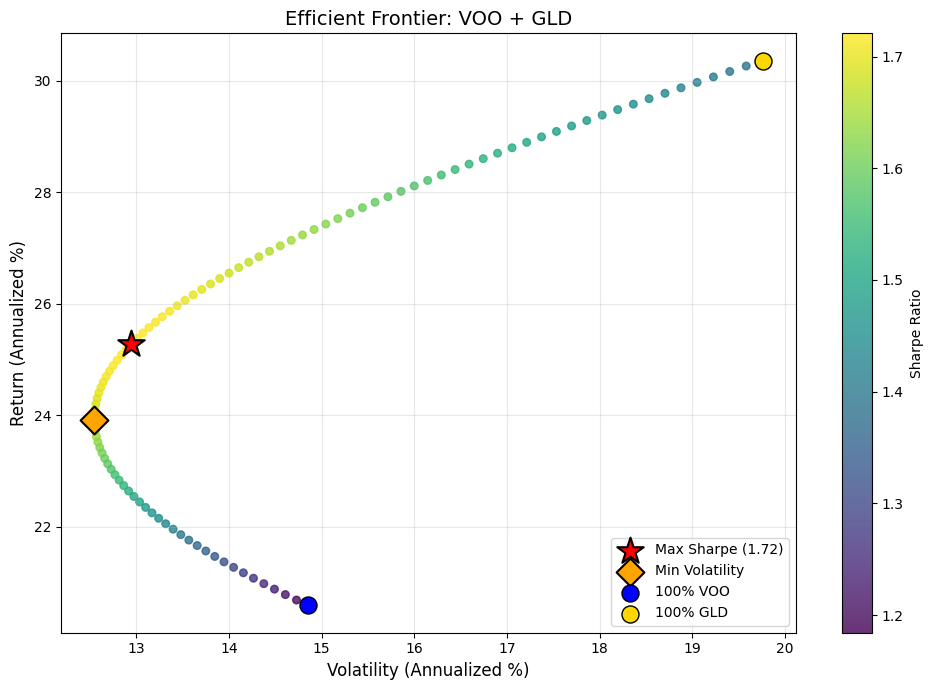


🎯 最大夏普组合：
   VOO 52% + GLD 48%
   年化收益 25.28%
   年化波动 12.95%
   夏普比率 1.721

🛡 最小波动组合：
   VOO 66% + GLD 34%
   年化收益 23.91%
   年化波动 12.55%


In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

# 用散点图，颜色代表夏普比率
scatter = ax.scatter(ef_df['vol']*100, ef_df['return']*100, 
                     c=ef_df['sharpe'], cmap='viridis', s=30, alpha=0.8)

# 标出特殊点
# 1. 最大夏普点
max_sharpe_idx = ef_df['sharpe'].idxmax()
ax.scatter(ef_df.loc[max_sharpe_idx, 'vol']*100, 
           ef_df.loc[max_sharpe_idx, 'return']*100,
           color='red', marker='*', s=400, edgecolor='black', 
           linewidth=1.5, label=f"Max Sharpe ({ef_df.loc[max_sharpe_idx, 'sharpe']:.2f})", zorder=5)

# 2. 最小波动点
min_vol_idx = ef_df['vol'].idxmin()
ax.scatter(ef_df.loc[min_vol_idx, 'vol']*100, 
           ef_df.loc[min_vol_idx, 'return']*100,
           color='orange', marker='D', s=200, edgecolor='black', 
           linewidth=1.5, label='Min Volatility', zorder=5)

# 3. 两个端点（纯 VOO、纯 GLD）
ax.scatter(ef_df.iloc[-1]['vol']*100, ef_df.iloc[-1]['return']*100,
           color='blue', marker='o', s=150, edgecolor='black', label='100% VOO', zorder=5)
ax.scatter(ef_df.iloc[0]['vol']*100, ef_df.iloc[0]['return']*100,
           color='gold', marker='o', s=150, edgecolor='black', label='100% GLD', zorder=5)

plt.colorbar(scatter, label='Sharpe Ratio')
ax.set_xlabel('Volatility (Annualized %)', fontsize=12)
ax.set_ylabel('Return (Annualized %)', fontsize=12)
ax.set_title('Efficient Frontier: VOO + GLD', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 打印关键权重
print(f"\n🎯 最大夏普组合：")
print(f"   VOO {ef_df.loc[max_sharpe_idx, 'w_VOO']*100:.0f}% + GLD {ef_df.loc[max_sharpe_idx, 'w_GLD']*100:.0f}%")
print(f"   年化收益 {ef_df.loc[max_sharpe_idx, 'return']*100:.2f}%")
print(f"   年化波动 {ef_df.loc[max_sharpe_idx, 'vol']*100:.2f}%")
print(f"   夏普比率 {ef_df.loc[max_sharpe_idx, 'sharpe']:.3f}")

print(f"\n🛡 最小波动组合：")
print(f"   VOO {ef_df.loc[min_vol_idx, 'w_VOO']*100:.0f}% + GLD {ef_df.loc[min_vol_idx, 'w_GLD']*100:.0f}%")
print(f"   年化收益 {ef_df.loc[min_vol_idx, 'return']*100:.2f}%")
print(f"   年化波动 {ef_df.loc[min_vol_idx, 'vol']*100:.2f}%")

In [18]:
np.random.seed(42)

n_portfolios = 10000
n_assets = len(returns.columns)
asset_names = returns.columns.tolist()

# 存结果
results = np.zeros((n_portfolios, 3))   # 收益、波动、夏普
all_weights = np.zeros((n_portfolios, n_assets))

# 年化预期收益 & 协方差矩阵（关键！）
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print("资产预期年化收益：")
print((mean_returns * 100).round(2))
print("\n协方差矩阵：")
print(cov_matrix.round(4))

# 开始模拟
for i in range(n_portfolios):
    # 生成随机权重，归一化到和为 1
    w = np.random.random(n_assets)
    w = w / w.sum()
    all_weights[i] = w
    
    # 组合预期收益（加权平均）
    port_ret = np.dot(w, mean_returns)
    
    # 组合预期波动（用协方差矩阵）
    # σ_p = √(w^T · Σ · w)
    port_vol = np.sqrt(w @ cov_matrix @ w)
    
    # 夏普
    port_sharpe = (port_ret - 0.03) / port_vol
    
    results[i] = [port_ret, port_vol, port_sharpe]

print(f"\n✅ 生成了 {n_portfolios} 个随机组合")

资产预期年化收益：
Ticker
GLD    30.3600
TLT    -1.5200
VGSH    4.0000
VOO    20.5900
VXUS   16.9000
dtype: float64

协方差矩阵：
Ticker    GLD    TLT    VGSH     VOO   VXUS
Ticker                                     
GLD    0.0390 0.0041  0.0008  0.0036 0.0106
TLT    0.0041 0.0203  0.0015  0.0026 0.0045
VGSH   0.0008 0.0015  0.0003 -0.0002 0.0002
VOO    0.0036 0.0026 -0.0002  0.0221 0.0170
VXUS   0.0106 0.0045  0.0002  0.0170 0.0217

✅ 生成了 10000 个随机组合


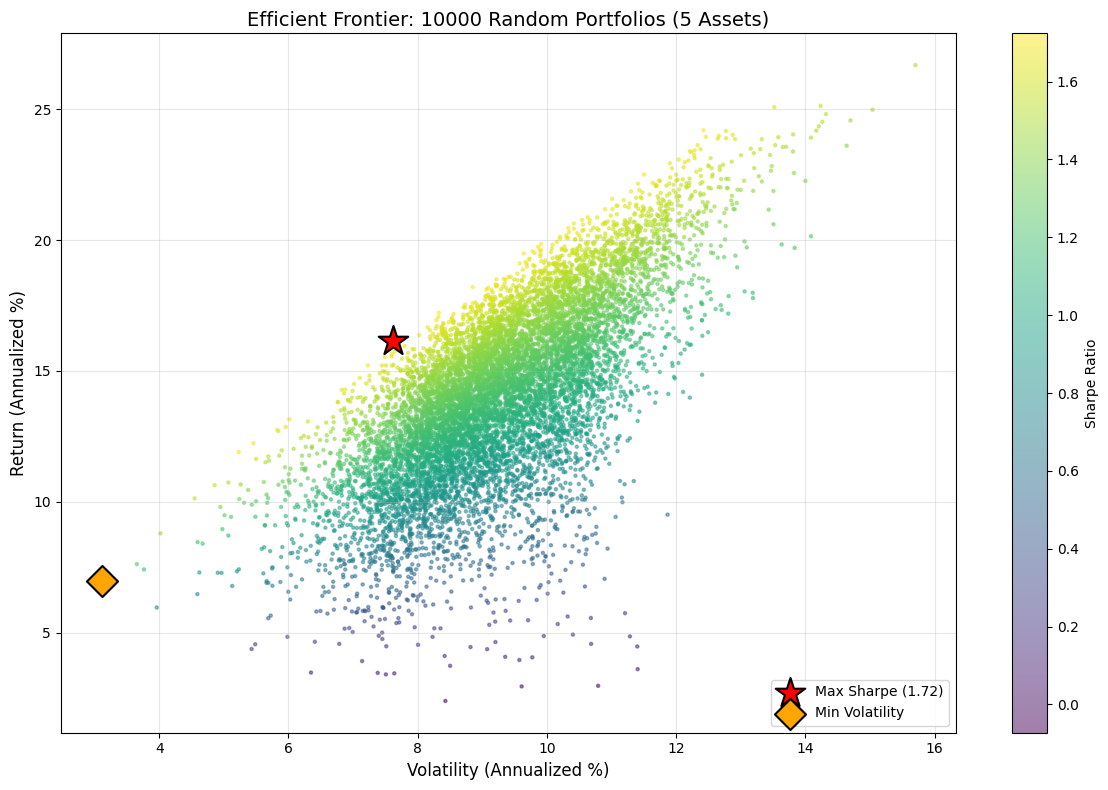


  🎯 最大夏普组合（Monte Carlo 近似解）
  GLD   :  26.61%
  TLT   :   0.99%
  VGSH  :  40.81%
  VOO   :  30.08%
  VXUS  :   1.50%
  Return:  16.14%
  Vol   :   7.62%
  Sharpe:  1.724

  🛡 最小波动组合
  GLD   :   3.36%
  TLT   :   4.85%
  VGSH  :  76.78%
  VOO   :  10.86%
  VXUS  :   4.16%
  Return:   6.95%
  Vol   :   3.11%


In [19]:
# 找到最大夏普组合
max_sharpe_idx = results[:, 2].argmax()
max_sharpe_w = all_weights[max_sharpe_idx]
max_sharpe_ret = results[max_sharpe_idx, 0]
max_sharpe_vol = results[max_sharpe_idx, 1]
max_sharpe_val = results[max_sharpe_idx, 2]

# 找到最小波动组合
min_vol_idx = results[:, 1].argmin()
min_vol_w = all_weights[min_vol_idx]
min_vol_ret = results[min_vol_idx, 0]
min_vol_vol = results[min_vol_idx, 1]

# 画图
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(results[:, 1]*100, results[:, 0]*100,
                     c=results[:, 2], cmap='viridis', s=5, alpha=0.5)

ax.scatter(max_sharpe_vol*100, max_sharpe_ret*100,
           color='red', marker='*', s=500, edgecolor='black',
           linewidth=1.5, label=f'Max Sharpe ({max_sharpe_val:.2f})', zorder=5)
ax.scatter(min_vol_vol*100, min_vol_ret*100,
           color='orange', marker='D', s=250, edgecolor='black',
           linewidth=1.5, label='Min Volatility', zorder=5)

plt.colorbar(scatter, label='Sharpe Ratio')
ax.set_xlabel('Volatility (Annualized %)', fontsize=12)
ax.set_ylabel('Return (Annualized %)', fontsize=12)
ax.set_title(f'Efficient Frontier: {n_portfolios} Random Portfolios (5 Assets)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 打印最优组合的权重
print("\n" + "="*60)
print("  🎯 最大夏普组合（Monte Carlo 近似解）")
print("="*60)
for name, w in zip(asset_names, max_sharpe_w):
    print(f"  {name:<6}: {w*100:>6.2f}%")
print(f"  {'Return':<6}: {max_sharpe_ret*100:>6.2f}%")
print(f"  {'Vol':<6}: {max_sharpe_vol*100:>6.2f}%")
print(f"  {'Sharpe':<6}: {max_sharpe_val:>6.3f}")

print("\n" + "="*60)
print("  🛡 最小波动组合")
print("="*60)
for name, w in zip(asset_names, min_vol_w):
    print(f"  {name:<6}: {w*100:>6.2f}%")
print(f"  {'Return':<6}: {min_vol_ret*100:>6.2f}%")
print(f"  {'Vol':<6}: {min_vol_vol*100:>6.2f}%")